<a href="https://colab.research.google.com/github/andreupn/Alboom-Association_and_Clustering/blob/main/Association.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#-- note: please add 'input_data_rekap' shortcut into your drive --#


Mounted at /content/drive


In [ ]:
# importing OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

#df_alboom = pd.read_excel('/content/drive/MyDrive/WG2/df_alboom_distance_cluster10.xlsx')
df_alboom = pd.read_excel('/content/drive/MyDrive/Klasifikasi_teks_BuHusnul/data klasifikasi teks.xlsx')
#df_alboom = pd.read_excel('/content/drive/MyDrive/WG2/alboom_16012023.xlsx')


In [ ]:
df_alboom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Unnamed: 0.2                         958 non-null    int64         
 1   Unnamed: 0                           958 non-null    int64         
 2   Unnamed: 0.1                         958 non-null    int64         
 3   id                                   958 non-null    object        
 4   Username                             958 non-null    object        
 5   accuracy                             958 non-null    float64       
 6   create_at                            958 non-null    datetime64[ns]
 7   start_date                           958 non-null    datetime64[ns]
 8   finish_date                          958 non-null    datetime64[ns]
 9   latitude                             958 non-null    float64       
 10  longitude     

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_alboom['jarak_terdekat'] = df_alboom[['Stasiun Meteorologi Radin Inten II', 'Stasiun Geofisika Lampung Utara', 'Stasiun Klimatologi Pesawaran', 'Stasiun Meteorologi Maritim Panjang']].min(axis=1)
df_alboom = df_alboom.sort_values('jarak_terdekat')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_alboom

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,id,Username,accuracy,create_at,start_date,finish_date,latitude,...,HABs Indication,Country,Provinsi,KotaKab,Stasiun Meteorologi Radin Inten II,Stasiun Geofisika Lampung Utara,Stasiun Klimatologi Pesawaran,Stasiun Meteorologi Maritim Panjang,cluster_label,jarak_terdekat
15,15,15,15,0d32e3999f60e002_9ef1bbc1-6657-4e10-825f-e9484...,Syahrudin Al Kautsar,2280.0,2022-03-13 10:36:39,2022-02-01 09:47:01,2022-02-01 09:57:24,-5.442420,...,No,Indonesia,Lampung,Bandar Lampung,38.28,83.03,33.19,3.63,0,3.63
200,200,200,200,2207d9d775f2e71e_4fb9b159-cc72-4502-b506-f828c...,Shofiyah Syakirah Han,25728.0,2021-11-10 20:05:57,2021-11-10 20:01:40,2021-11-10 20:04:05,-5.192137,...,No,Indonesia,Lampung,Lampung Selatan,11.59,54.61,3.94,33.50,0,3.94
339,339,339,339,42d5846ab5bddd97_dfe8cdcf-d5b5-4fa9-adf1-7c675...,Wawan subandi,15621.0,2022-07-22 09:36:17,2022-07-22 09:34:04,2022-07-22 09:35:34,-5.485488,...,No,Indonesia,Lampung,Bandar Lampung,40.55,85.00,36.38,5.32,0,5.32
308,308,308,308,42d5846ab5bddd97_20c969ae-ed76-448e-b8ba-8b07b...,Wawan subandi,1678.0,2022-04-21 14:15:18,2022-04-21 14:11:38,2022-04-21 14:15:13,-5.486624,...,No,Indonesia,Lampung,Bandar Lampung,40.61,85.05,36.47,5.46,0,5.46
357,357,357,357,470367896a899b36_098b4322-d66d-4e34-a916-6ea9a...,Edo,6.4,2022-01-22 11:28:18,2022-01-20 17:06:39,2022-01-20 17:08:35,-5.448970,...,No,Indonesia,Lampung,Bandar Lampung,36.92,81.52,32.48,5.81,0,5.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,512,512,512,6c4a3f1f7fd59219_d401999d-514b-41ed-9722-e8387...,SANTI,0.0,2022-09-15 21:05:08,2022-09-15 21:02:33,2022-09-16 19:15:36,0.000000,...,Unsure,GeoLocNotValid,GeoLocNotValid,GeoLocNotValid,11684.40,11658.65,11692.11,11706.88,1,11658.65
956,956,956,956,fd2dbfeba1e57ebd_9f509db3-2f21-4c8d-a765-22124...,Jeriko Lamhot Nababan,0.0,2021-11-21 14:32:18,2021-11-21 14:24:13,2021-11-21 14:28:52,0.000000,...,No,GeoLocNotValid,GeoLocNotValid,GeoLocNotValid,11684.40,11658.65,11692.11,11706.88,1,11658.65
471,471,471,471,666711342ef27198_32c76b24-d775-43fe-8079-72694...,Yusuf Saady,0.0,2021-11-17 16:40:48,2021-11-09 12:32:21,2021-11-17 16:40:46,0.000000,...,No,GeoLocNotValid,GeoLocNotValid,GeoLocNotValid,11684.40,11658.65,11692.11,11706.88,1,11658.65
398,398,398,398,55ff368c0160e015_d95f0280-db79-4cbe-acb3-87f37...,Bambang Eka Mudi,0.0,2021-11-08 11:13:21,2021-11-08 11:02:55,2021-11-08 11:13:18,0.000000,...,No,GeoLocNotValid,GeoLocNotValid,GeoLocNotValid,11684.40,11658.65,11692.11,11706.88,1,11658.65


In [ ]:
#df_alboom.to_excel('/content/drive/MyDrive/WG2/cluster_jarak.xlsx')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<function matplotlib.pyplot.show(close=None, block=None)>

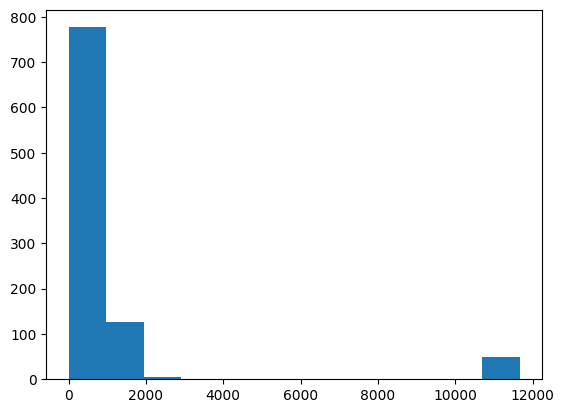

In [ ]:
plt.hist(df_alboom['jarak_terdekat'], bins = 12)
plt.show

In [ ]:
df_apriori = df_alboom.drop(df_alboom.columns[[0,1, 2,3,4,5,6,7,8,9, 10,11,12,13, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20]],axis = 1)
#df_apriori

df_kondisi_air = df_apriori.iloc[:, 0:9]
df_kondisi_cuaca = df_apriori.iloc[:, 10:15]
#df_kondisi_cuaca
df_kondisi_air


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Warna Air,Kepekatan Air,Gumpalan Masa,Lendir,Buih Gelembung,Gatal,BercahayaBerpendar,Luasan Perubahan,Suhu Air
15,hijau tua,encer (normal,tidak ada,tidak,tidak ada,tidak,ya,ya,dingin
200,tidak ada perubahan,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak tahu,tidak tahu,dingin
339,hijau tua,encer (normal,ada,ya,tidak ada,tidak,ya,ya,normal
308,hijau muda,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal
357,coklat tua,air pekat,tidak ada,ya,ada,tidak,tidak,tidak,dingin
...,...,...,...,...,...,...,...,...,...
512,hijau tua,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal
956,coklat muda,encer (normal,tidak ada,ya,ada,tidak,tidak,ya,normal
471,coklat tua,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak tahu,tidak tahu,normal
398,tidak ada perubahan,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal


In [ ]:
df_kondisi_air.rename(
    columns={"Warna Air":"water_colour",
                "Kepekatan Air":"water_density",
                    "Gumpalan Masa": "clumpy_mass",
                        "Buih Gelembung":"foamy",
                            "Luasan Perubahan":"luasan_perubahan",
                                "Suhu Air":"water_temperature",
                                    "Lendir": "slimy_feel",
                                        "Gatal": "itchy",
                                            "BercahayaBerpendar": "bioluminescence"
                                          }
          ,inplace=True)
df_kondisi_air

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-8-c08354e602d2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kondisi_air.rename(


,water_colour,water_density,clumpy_mass,slimy_feel,foamy,itchy,bioluminescence,luasan_perubahan,water_temperature
15,hijau tua,encer (normal,tidak ada,tidak,tidak ada,tidak,ya,ya,dingin
200,tidak ada perubahan,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak tahu,tidak tahu,dingin
339,hijau tua,encer (normal,ada,ya,tidak ada,tidak,ya,ya,normal
308,hijau muda,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal
357,coklat tua,air pekat,tidak ada,ya,ada,tidak,tidak,tidak,dingin
...,...,...,...,...,...,...,...,...,...
512,hijau tua,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal
956,coklat muda,encer (normal,tidak ada,ya,ada,tidak,tidak,ya,normal
471,coklat tua,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak tahu,tidak tahu,normal
398,tidak ada perubahan,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal


In [ ]:
df_kondisi_cuaca.rename(
    columns={"Penyinaran Matahari":"Penyinaran_Matahari",
                "Hujan Saat Pengamatan":"Hujan_Saat_Pengamatan",
                    "Hujan Sebelum Pengamatan": "Hujan_Sebelum_Pengamatan",
                        "Suhu Udara":"Suhu_Udara"}
          ,inplace=True)
df_kondisi_cuaca

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-9-caea69ed4e6c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kondisi_cuaca.rename(


,Penyinaran_Matahari,Hujan_Saat_Pengamatan,Hujan_Sebelum_Pengamatan,Angin,Suhu_Udara
15,cerah,tidak hujan,gerimis,sepoi-sepoi,panas
200,cerah,tidak hujan,gerimis,sepoi-sepoi,panas
339,berawan,tidak hujan,gerimis,sepoi-sepoi,normal
308,berawan,tidak hujan,hujan lebat,sepoi-sepoi,normal
357,berawan,hujan lebat,gerimis,angin bertiup kencang,dingin
...,...,...,...,...,...
512,terik,tidak hujan,hujan lebat,sepoi-sepoi,normal
956,terik,tidak hujan,hujan lebat,sepoi-sepoi,panas
471,terik,tidak hujan,gerimis,tidak ada angin,panas
398,berawan,tidak hujan,hujan lebat,sepoi-sepoi,normal


In [ ]:
df_kondisi_combine = pd.concat([df_kondisi_cuaca, df_kondisi_air], axis=1)
df_kondisi_combine

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Penyinaran_Matahari,Hujan_Saat_Pengamatan,Hujan_Sebelum_Pengamatan,Angin,Suhu_Udara,water_colour,water_density,clumpy_mass,slimy_feel,foamy,itchy,bioluminescence,luasan_perubahan,water_temperature
15,cerah,tidak hujan,gerimis,sepoi-sepoi,panas,hijau tua,encer (normal,tidak ada,tidak,tidak ada,tidak,ya,ya,dingin
200,cerah,tidak hujan,gerimis,sepoi-sepoi,panas,tidak ada perubahan,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak tahu,tidak tahu,dingin
339,berawan,tidak hujan,gerimis,sepoi-sepoi,normal,hijau tua,encer (normal,ada,ya,tidak ada,tidak,ya,ya,normal
308,berawan,tidak hujan,hujan lebat,sepoi-sepoi,normal,hijau muda,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal
357,berawan,hujan lebat,gerimis,angin bertiup kencang,dingin,coklat tua,air pekat,tidak ada,ya,ada,tidak,tidak,tidak,dingin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,terik,tidak hujan,hujan lebat,sepoi-sepoi,normal,hijau tua,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal
956,terik,tidak hujan,hujan lebat,sepoi-sepoi,panas,coklat muda,encer (normal,tidak ada,ya,ada,tidak,tidak,ya,normal
471,terik,tidak hujan,gerimis,tidak ada angin,panas,coklat tua,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak tahu,tidak tahu,normal
398,berawan,tidak hujan,hujan lebat,sepoi-sepoi,normal,tidak ada perubahan,encer (normal,tidak ada,tidak,tidak ada,tidak,tidak,tidak,normal


In [ ]:
# one-hot encoding

df_kondisi_air_ohe = pd.get_dummies(df_kondisi_air)
df_kondisi_air_ohe

df_kondisi_cuaca_ohe = pd.get_dummies(df_kondisi_cuaca)
#df_kondisi_cuaca_ohe

df_kondisi_combine_ohe = pd.get_dummies(df_kondisi_combine)
#df_kondisi_combine_ohe


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# checking features
cat = df_kondisi_air.select_dtypes(include='O').keys()
# display variabels
cat

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Index(['water_colour', 'water_density', 'clumpy_mass', 'slimy_feel', 'foamy',
       'itchy', 'bioluminescence', 'luasan_perubahan', 'water_temperature'],
      dtype='object')

In [ ]:
# unique values in each columns
for x in df_kondisi_cuaca.columns:
    #prinfting unique values
    print(x ,':', len(df_kondisi_cuaca[x].unique()))

Penyinaran_Matahari : 4
Hujan_Saat_Pengamatan : 4
Hujan_Sebelum_Pengamatan : 4
Angin : 4
Suhu_Udara : 4


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# finding the top 20 categories
#df_kondisi_cuaca.Penyinaran_Matahari.value_counts().sort_values(ascending=False).head(20)
df_alboom.KotaKab.value_counts().sort_values(ascending=False).head(20)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Pesawaran                      241
Bandar Lampung                 186
-                               59
Jembrana                        55
GeoLocNotValid                  49
Desa Babakan                    35
Banyuasin                       22
Desa Pagandaran                 19
Kabupaten Kepulauan Meranti     14
Lampung Selatan                 13
Lingga                          13
Pagar Alam                      12
Bangka                          11
Padang                          11
Semarang                        10
Lombok Utara                    10
Barru                           10
Palembang                       10
Tegal                            8
Kota Bekasi                      8
Name: KotaKab, dtype: int64

In [ ]:
#freq_items = apriori(df_kondisi_air_ohe, min_support=0.1, use_colnames=True)
#freq_items
#.head(10)
#freq_items = apriori(df_kondisi_cuaca_ohe, min_support=0.1, use_colnames=True)

#freq_items = apriori(df_kondisi_combine_ohe, min_support=0.1, use_colnames=True)
freq_items

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets
0,0.444676,(Penyinaran_Matahari_berawan)
1,0.341336,(Penyinaran_Matahari_cerah)
2,0.207724,(Penyinaran_Matahari_terik)
3,0.106472,(Hujan_Saat_Pengamatan_gerimis)
4,0.853862,(Hujan_Saat_Pengamatan_tidak hujan)
...,...,...
15173,0.115866,"(clumpy_mass_tidak ada, water_colour_tidak ada..."
15174,0.128392,"(clumpy_mass_tidak ada, Suhu_Udara_normal, wat..."
15175,0.100209,"(Hujan_Sebelum_Pengamatan_gerimis, clumpy_mass..."
15176,0.124217,"(clumpy_mass_tidak ada, Suhu_Udara_normal, wat..."


In [ ]:
rules = association_rules(freq_items, metric="confidence", min_threshold=1)
rules

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"(water_colour_hijau muda, bioluminescence_tidak)",(itchy_tidak),0.128392,0.926931,0.128392,1.0,1.078829,0.009381,inf,0.083832
1,"(bioluminescence_tidak, water_colour_hijau tua)",(itchy_tidak),0.157620,0.926931,0.157620,1.0,1.078829,0.011517,inf,0.086741
2,"(Penyinaran_Matahari_cerah, bioluminescence_ti...",(itchy_tidak),0.186848,0.926931,0.186848,1.0,1.078829,0.013653,inf,0.089859
3,"(Hujan_Saat_Pengamatan_tidak hujan, Hujan_Sebe...",(clumpy_mass_tidak ada),0.127349,0.864301,0.127349,1.0,1.157005,0.017281,inf,0.155502
4,"(Hujan_Saat_Pengamatan_tidak hujan, water_colo...",(itchy_tidak),0.110647,0.926931,0.110647,1.0,1.078829,0.008085,inf,0.082160
...,...,...,...,...,...,...,...,...,...,...
2716,"(water_colour_tidak ada perubahan, clumpy_mass...",(water_density_encer (normal),0.124217,0.858038,0.124217,1.0,1.165450,0.017634,inf,0.162098
2717,"(water_colour_tidak ada perubahan, clumpy_mass...","(water_density_encer (normal, itchy_tidak)",0.124217,0.824635,0.124217,1.0,1.212658,0.021783,inf,0.200238
2718,"(water_colour_tidak ada perubahan, clumpy_mass...",(itchy_tidak),0.112735,0.926931,0.112735,1.0,1.078829,0.008237,inf,0.082353
2719,"(water_colour_tidak ada perubahan, clumpy_mass...",(water_density_encer (normal),0.112735,0.858038,0.112735,1.0,1.165450,0.016004,inf,0.160000


In [ ]:
rules.to_excel('/content/drive/MyDrive/WG2/apriori_combination_confidence_1.xlsx')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
